# Métropole du Grand Nancy

# 0. Configuration

In [188]:
import os
import sys
import numpy as np
import geopandas as gpd
import ee
import matplotlib.pyplot as plt

# personal modules
sys.path.insert(1, '../../marion/corridor_project/modules/')
import landcover as lc
import connectivity as conn
import routing as rout
sys.path.insert(1, '../../marion/corridor_project/config/')
import species_params

# Authentification GEE
service_account = 'gee-141@gee161025.iam.gserviceaccount.com'
credentials_path = '../../marion/credentials/gee161025-533af22f806b.json'
credentials = ee.ServiceAccountCredentials(service_account, credentials_path)
ee.Initialize(credentials)

# case study def
CITY = "Nancy"
GUILD_KEY = "mid_walker"
specie = species_params.SPECIES_CONFIG[GUILD_KEY]
OUTPUT_DIR = f"/home/jovyan/work/team/marion/corridor_project/results_connectivity/{CITY}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paramètres AOI
url_aoi = "https://geo.api.gouv.fr/epcis?nom=Grand%20Nancy&format=geojson&geometry=contour"
aoi_raw = gpd.read_file(url_aoi)
dept = "D054"

Skipping field codesDepartements: unsupported OGR type: 5
Skipping field codesRegions: unsupported OGR type: 5


In [189]:
import importlib
from modules import landcover as lc
from modules import connectivity as conn
from modules import routing as rout
import species_params
importlib.reload(lc)
importlib.reload(conn)
importlib.reload(rout)
importlib.reload(species_params)

<module 'species_params' from '/home/jovyan/work/team/marion/corridor_project/../../marion/corridor_project/config/species_params.py'>

# 1. Landcover

Landcover raster combining ESA WorldCover and OSM Highways

In [190]:
aoi_utm, aoi_ee, utm_epsg = lc.setup_aoi(aoi_raw)
da_lc = lc.get_city_landcover(aoi_ee, aoi_utm, aoi_raw, utm_epsg)
print(f"Valeurs : {np.unique(da_lc.values)}")

da_export = da_lc.fillna(0).astype('uint8')
da_export.rio.to_raster(f"{OUTPUT_DIR}/landcover_{CITY}.tif")

Valeurs : [10. 30. 40. 50. 51. 52. 60. 80. 90. nan]


# 2. Habitat Morphology - MSPA

Identifies morphological connectivity elements (nodes and stepping stones) based on species preferences

In [191]:
habitat_codes = specie['habitat_codes']
binary_wc = conn.get_binary_habitat(da_lc, habitat_codes)

gdf_cores, gdf_islets = conn.get_connectivity_elements(binary_wc, core_min_ha=1.0, islet_min_ha=0.2)
print(f"✓ {len(gdf_cores)} Noyaux de biodiversité et {len(gdf_islets)} Stepping Stones (Islets + Petits Cores) identifiés.")

# binary_wc.rio.to_raster(f"{OUTPUT_DIR}/binary_habitat_{CITY}.tif")
# gdf_cores.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_islets.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_cores.to_file(f"{OUTPUT_DIR}/cores_{CITY}.json", driver='GeoJSON')
# gdf_islets.to_file(f"{OUTPUT_DIR}/islets_{CITY}.json", driver='GeoJSON')

✓ 210 Noyaux de biodiversité et 1066 Stepping Stones (Islets + Petits Cores) identifiés.


# 3. Graph Connectivity Analysis

## 3.1. Network modeling

The landscape is modeled as a graph where Nodes represent habitat patches and Edges represent potential dispersal links.
- Probabilistic approach: Connection strength is based on an exponential decay function relative to the species dispersal distance ($d_0$) - probability of movement between patches.
- Topology: Edges are identified using a K-Nearest Neighbors (KNN) algorithm, where the $k$ set increases with the species dispersal capabilities.

In [192]:
df_nodes = conn.prepare_graph_nodes(gdf_cores, gdf_islets)
G = conn.build_connectivity_graph_knn(df_nodes, specie)

Graphe construit : 1276 nœuds et 6113 arêtes.


## 3.2. Theoretical PC index

Probability of Connectivity (PC) Index measures landscape permeability for a given functional guild. It represents the probability that 2 points randomly placed in the city fall within connected habitat patches.

In [193]:
total_area_km2 = aoi_utm.area.sum() / 1e6
pc_value = conn.calculate_pc_index(G, total_area_km2)
print(f"Indice PC pour {CITY} : {pc_value:.6f}")

gdf_edges = conn.graph_to_gdf_edges(G, utm_epsg)
# gdf_edges.to_file(f"{OUTPUT_DIR}/edges_{CITY}.json", driver='GeoJSON')

Indice PC pour Nancy : 0.032520


# 4. Least Cost Path Analysis

From euclidean distance to real-world distance that accounts for landscape friction. Simulation of the optimal path for a given species between each node.

In [194]:
gdf_lcp = rout.compute_lcp_network(gdf_edges, df_nodes, da_lc, specie['friction'])

gdf_lcp['tortuosity'] = gdf_lcp['real_dist'] / gdf_lcp['theoretical_dist']
print(f"Average Tortuosity for {CITY}: {gdf_lcp['tortuosity'].mean():.3f}")

Tracing LCPs: 100%|██████████| 6113/6113 [07:17<00:00, 13.96it/s]

Average Tortuosity for Nancy: 2.213


## 4.1. Network metrics: PC

By comparing the Theoretical PC (Euclidean from Graph) with the Real PC (LCP), we quantify the connectivity loss. This delta quantifies the impact of human infrastructure and urban matrix on species mobility.

In [195]:
pc_real, G_lcp = conn.calculate_pc_index_lcp(G=G, total_area_km2=total_area_km2, species_params=specie, gdf_lcp=gdf_lcp)
print(f"Theoretical PC (euclidian) : {pc_value:.6f}")
print(f"Real PC (LCP) : {pc_real:.6f}")
print(f"Fragmentation impact : {((pc_value - pc_real) / pc_value)*100:.1f}% connectivity loss.")

Theoretical PC (euclidian) : 0.032520
Real PC (LCP) : 0.023548
Fragmentation impact : 27.6% connectivity loss.


## 4.2. Corridors metrics: dPC, ebc

Identify critical links for network maintenance using two complementary metrics: 
- dPC (Flux): Ranks corridors by the volume of biodiversity flow they facilitate. Based on the overall PC index, measures the contribution of a single link to the total probability of connectivity across the landscape. Weighted by the surface area of the habitats connected, and dispersal probability between them. Prioritizes quantity (link between 2 massive reservoirs).
- Edge Betweenness Centrality (Rarity) : Highlights bottlenecks / bridge corridors vital for network cohesion. Measures how often a specific corridor is used as a "shortest path" to connect all possible pairs of habitats in the network. Their loss would fragment the system into isolated sub-units, they act as the only available path between distant parts of the network, regardless of the size of the patches they link. 

In [150]:
# dpc flux
gdf_lcp = conn.calculate_edge_dpc(gdf_lcp, G_lcp, total_area_km2, pc_real)

# edge betweenness centrality proxy dpc edge connector
gdf_lcp = conn.calculate_edge_betweenness(gdf_lcp, G_lcp)

### 4.2.1. Corridors categories

| Flow (dPC) | Rarity (EBC) | Corridor category |  
| :--- | :--- | :--- |   
| **High** | **High** | Ecological highway |  
| **Low** | **High** | Strategic bottleneck |  
| **High** | **Low** | Redundant mesh |  
| **Low** | **Low** | Local link |  

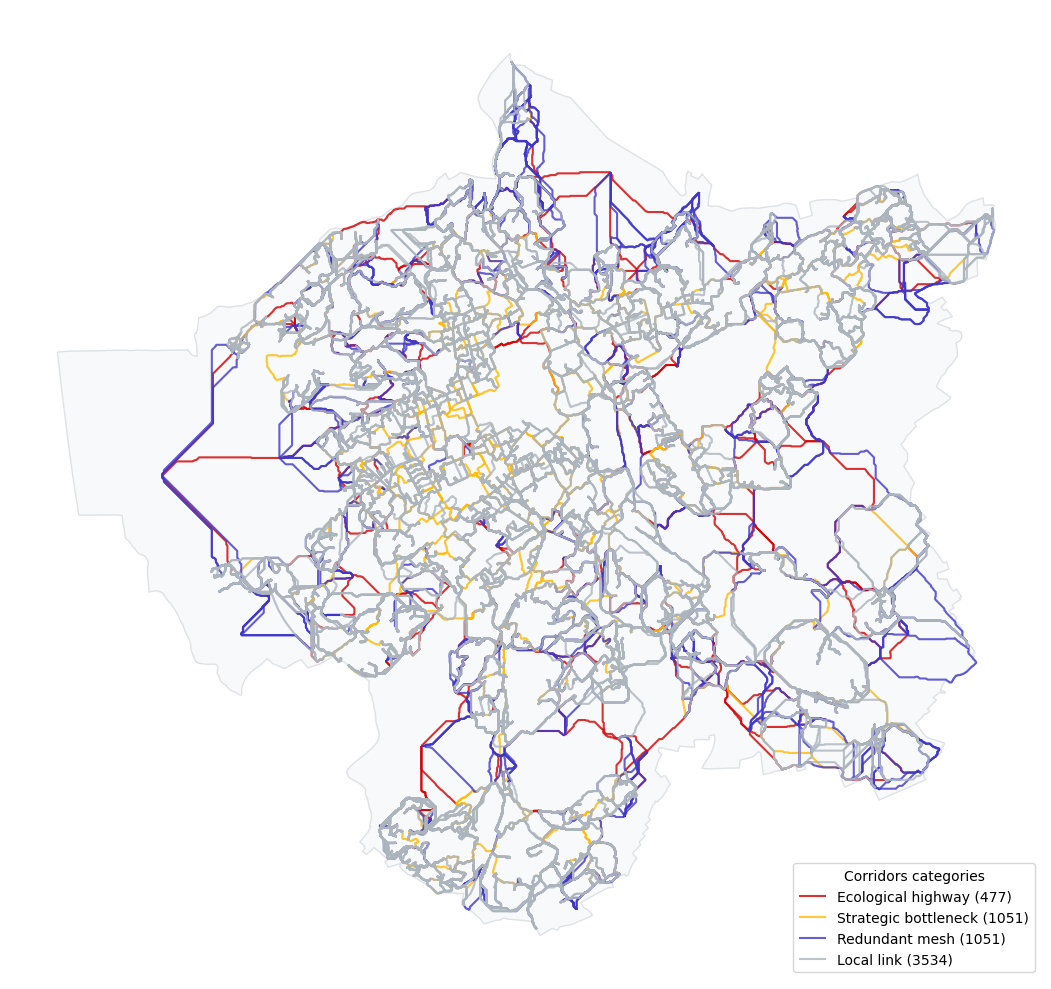

In [152]:
gdf_lcp = conn.classify_and_plot_corridors(gdf_lcp, aoi_utm, 0.75)
# gdf_lcp.to_file(f"{OUTPUT_DIR}/lcp_{CITY}.json", driver='GeoJSON')

### 4.2.2. Heatmap, connectivity density

In [181]:
da_heatmap = conn.lcp_heatmap(gdf_lcp, aoi_utm, res=10, crs_utm=utm_epsg)
# da_heatmap.rio.to_raster(f"{OUTPUT_DIR}/heatmap_lcp_{CITY}.tif")

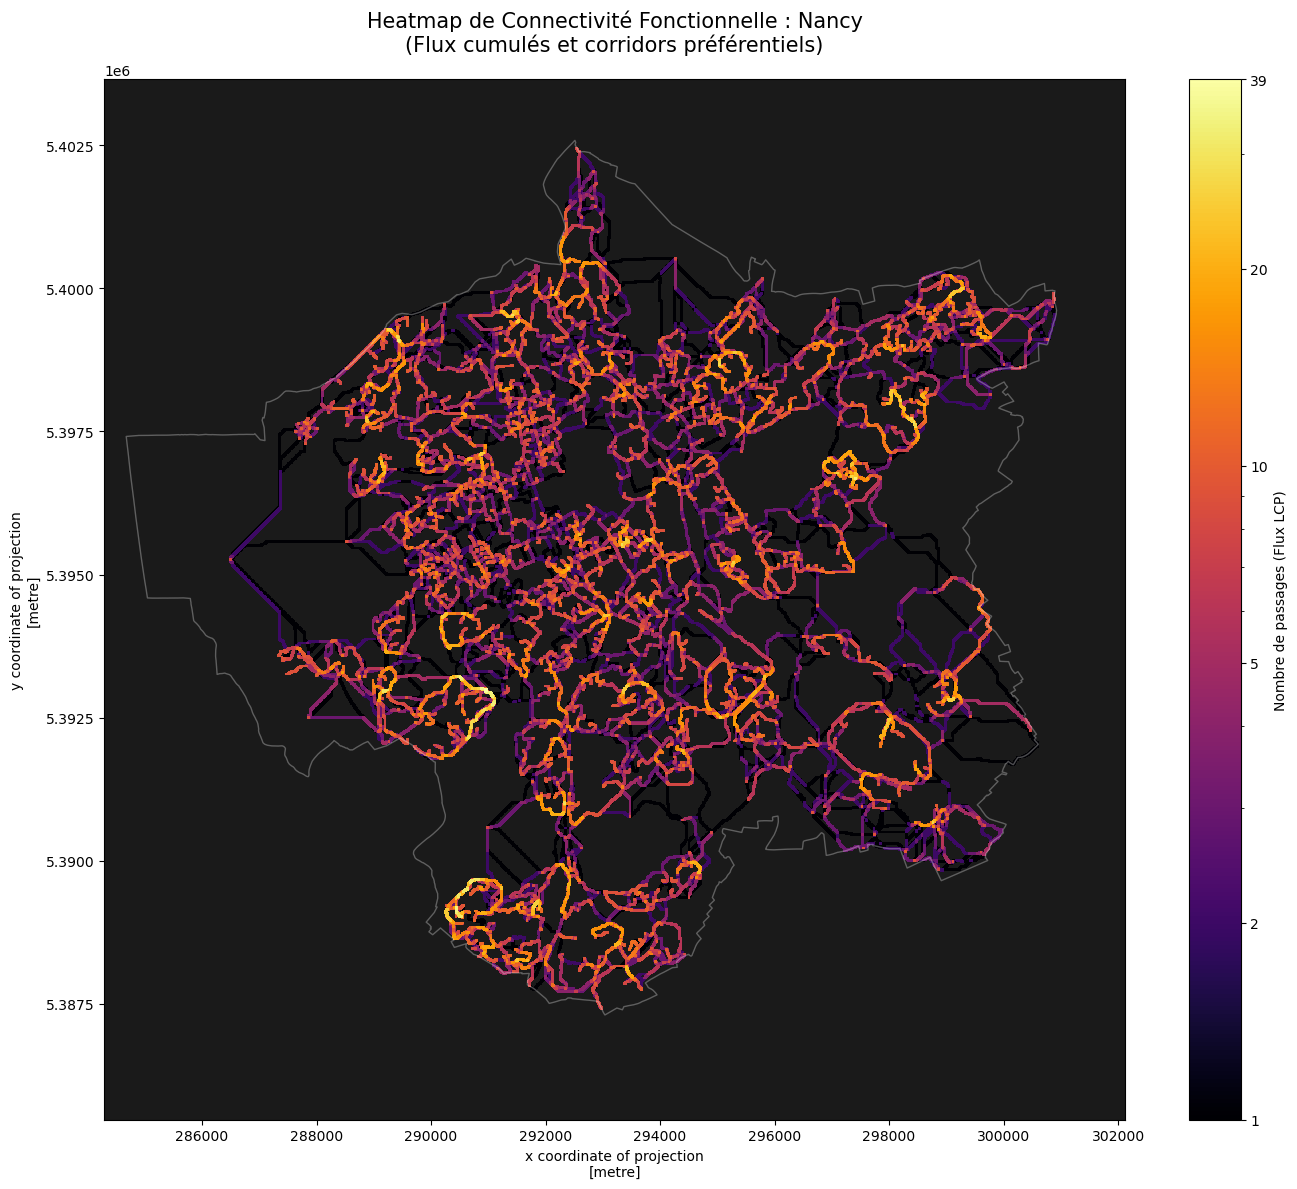

In [187]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import ScalarFormatter
from scipy import ndimage

# On dilate la heatmap de qq pixels pour rendre les corridors plus "épais" visuellement
dilated_data = ndimage.maximum_filter(da_heatmap.values, size=3) 
da_heatmap_thick = da_heatmap.copy(data=dilated_data)

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('#1a1a1a')

# On masque les 0 pour qu'ils ne tirent pas l'échelle vers le bas
heatmap_plot = da_heatmap_thick.where(da_heatmap_thick > 0)

vmax = int(da_heatmap_thick.max())
im = heatmap_plot.plot(
    ax=ax,
    cmap='inferno', 
    norm=colors.LogNorm(vmin=1, vmax=vmax),
    add_colorbar=True,
    cbar_kwargs={
        'label': 'Nombre de passages (Flux LCP)',
        'format': ScalarFormatter(), 
        'ticks': [1, 2, 5, 10, 20, vmax]
    }
)

# On ajoute l'AOI pour les limites de la ville
aoi_utm.plot(ax=ax, facecolor="none", edgecolor="white", alpha=0.3)

plt.title(f"Heatmap de Connectivité Fonctionnelle : {CITY}\n(Flux cumulés et corridors préférentiels)", fontsize=15, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

## 4.3. Nodes metrics: dPC

Analysis of the contribution of each patch to the global network. Connector fraction of the dPC index, which identifies patches that act as essential topological relays between other nodes, regardless of their own intrinsic area.
> warning : very long to compute, iterative node-removal simulations.

In [127]:
df_nodes_connector = conn.calculate_node_dpc(G_lcp, total_area_km2, species_params=specie)
gdf_nodes = df_nodes.merge(df_nodes_connector, left_index=True, right_on='node_id')
gdf_nodes.set_crs(utm_epsg, inplace=True, allow_override=True)
gdf_nodes.to_file(f"{OUTPUT_DIR}/dpc_nodes_{CITY}.json", driver='GeoJSON')

Analyse de connectivité pour 1904 noyaux...


Calcul dPC Nodes:   0%|          | 0/1904 [00:12<?, ?node/s]


KeyboardInterrupt: 

______
# ***WIP***

# 5. Circuit Theory

Proxy flou gaussien au lieu de lois de Kirchoff résistance pour chaque pixel  
Définir les sources et les grounds  
Use a Cost-Distance Accumulation surface instead of just a Gaussian blur to show where paths converge.

## 5.1. Carte de conductance

In [155]:
# 1. Récupération de la friction spécifique à la guilde
friction_dict = specie['friction']

# 2. Création de la carte de friction (Reclassement)
# On initialise avec une valeur par défaut élevée pour les codes inconnus
da_friction = xr.where(da_lc.isnull(), 1000, 1000) 

for code, weight in friction_dict.items():
    da_friction = xr.where(da_lc == code, weight, da_friction)

# 3. Calcul de la Conductance brute (1 / Friction)
da_conductance = 1.0 / (da_friction + 0.1)

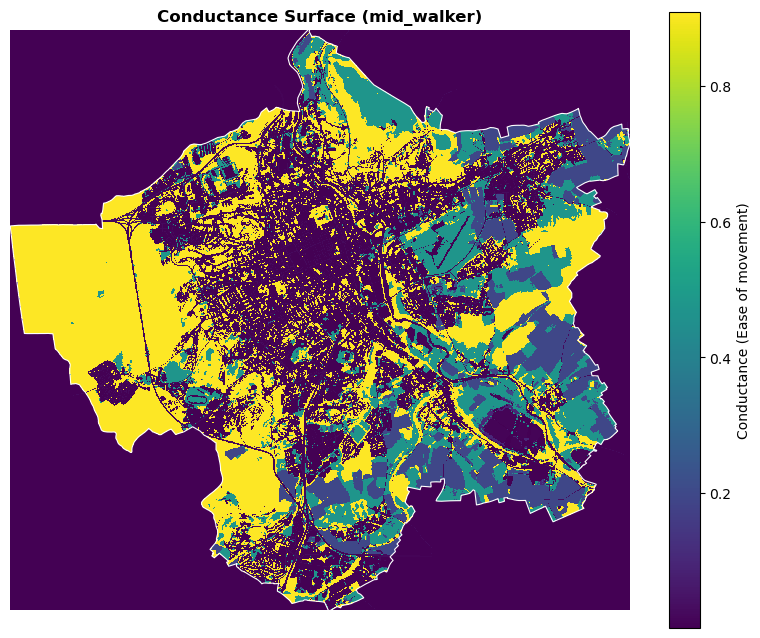

In [156]:
fig, ax = plt.subplots(figsize=(10, 8))

da_conductance.plot(
    ax=ax, 
    cmap='viridis', # jaune = passage facile, violet = barrière
    cbar_kwargs={'label': 'Conductance (Ease of movement)'}
)

aoi_utm.boundary.plot(ax=ax, color='white', linewidth=0.8)

ax.set_title(f"Conductance Surface ({GUILD_KEY})", fontweight='bold')
ax.set_axis_off()
plt.show()

## 5.2. Pinch points

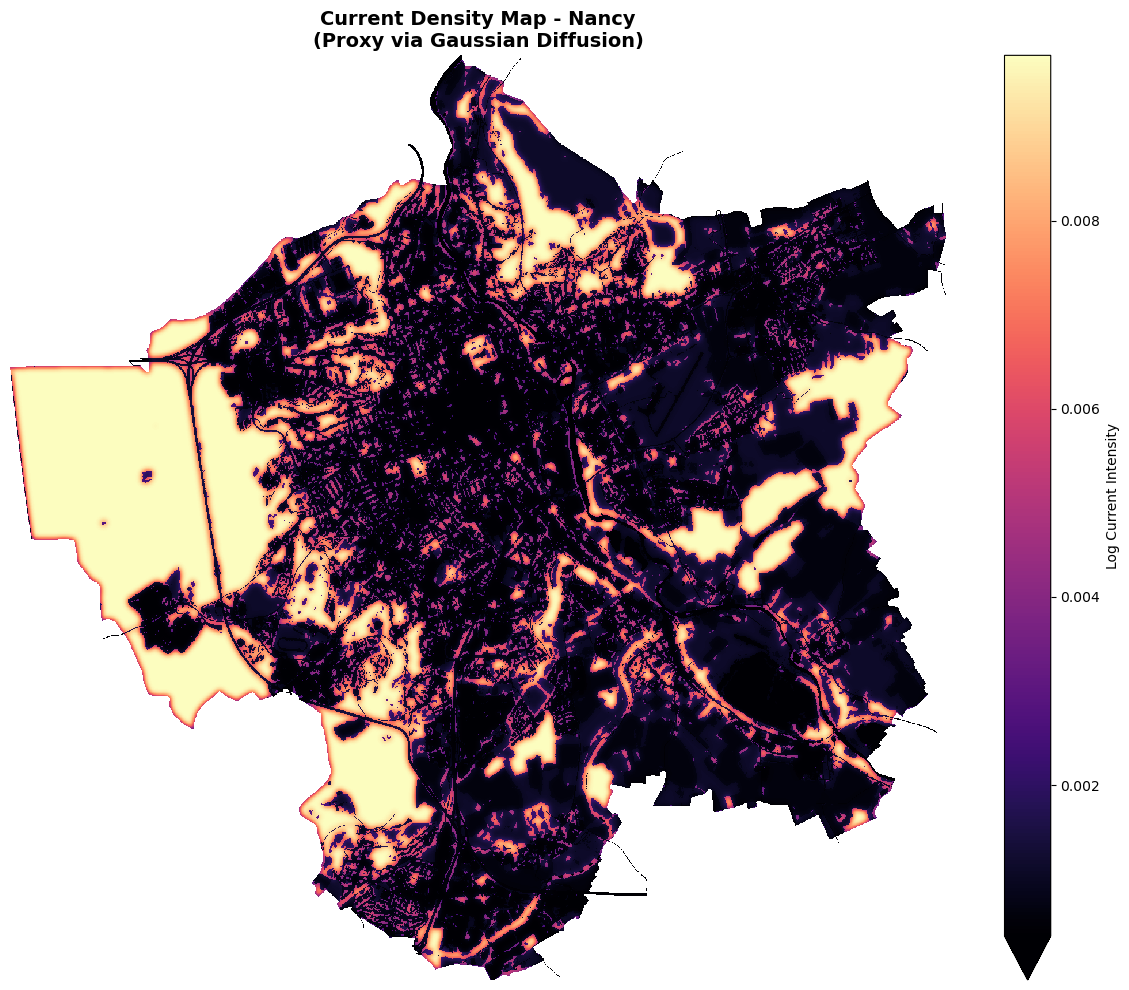

In [157]:
from scipy.ndimage import gaussian_filter

def calculate_pinch_points_proxy(da_friction, sigma=5):
    # Gestion des NaNs
    mask = da_friction.isnull()
    clean_friction = da_friction.fillna(da_friction.max())
    
    # 1. Conductance (Inverse de la friction)
    conductance = 1.0 / (clean_friction + 0.1)
    
    # 2. Diffusion proxy (Sigma plus élevé pour mieux voir les corridors)
    flow_spread = gaussian_filter(conductance.values, sigma=sigma)
    
    # Intensité de courant
    current_density = flow_spread * conductance.values
    
    da_current = da_friction.copy(data=current_density)
    return da_current.where(~mask)

# 1. Calcul
da_current_map = calculate_pinch_points_proxy(da_lc, sigma=5)

# 2. Visualisation simple
fig, ax = plt.subplots(figsize=(12, 10))

# On utilise log1p pour compresser la dynamique et voir les détails urbains
np.log1p(da_current_map).plot(
    ax=ax, 
    cmap='magma', 
    robust=True, 
    cbar_kwargs={'label': 'Log Current Intensity'}
)

ax.set_title(f"Current Density Map - {CITY}\n(Proxy via Gaussian Diffusion)", fontsize=14, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.show()